# Adzuna 行业级招聘热度 Pipeline
### Lloyds BCB 毕设项目 — Sector Hiring Score

Adzuna 相当于关键词搜索引擎，不是公司级数据库。  
按公司名搜索返回结果噪声极大（已验证），因此招聘维度的数据改为**行业级聚合**：

```
预定义行业关键词
      ↓
按关键词批量搜 Adzuna（英国市场）
      ↓
去重、聚合成 4 个子维度评分
      ↓
sector_hiring_score（0–100）
      ↓
merge 回 company_master
（同行业所有公司共享该背景分，作为调节系数）
```

**在 Opportunity Score 中的定位**

```
Opportunity Score =
    0.50 × company_filing_score    ← 公司级主体（Companies House）
  + 0.30 × sector_hiring_score     ← 行业背景权重（本 notebook 输出）
  + 0.20 × company_age_score       ← 公司级辅助
```


## 0. 环境安装与导入

In [ ]:
# 首次运行取消注释
# !pip install requests pandas tqdm

In [1]:
import os
import re
import time
import sqlite3
import json
import logging
from pathlib import Path
from datetime import datetime, timezone

import requests
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from tqdm.notebook import tqdm

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
log = logging.getLogger(__name__)

print("导入完成")

导入完成


## 1. 配置参数

In [2]:
# Adzuna API 
ADZUNA_APP_ID  = "9d40f51d"
ADZUNA_APP_KEY = "6a151e5f23976ded9a47ce1cf059df04"
COUNTRY        = "gb"           # 英国市场
RESULTS_PER_PAGE = 50
MAX_PAGES_PER_KW = 3            # 每个关键词最多抓 3 页（150条）
REQUEST_SLEEP    = 0.5          # 每次请求间隔（秒）

# ─── 路径配置 ──────────────────────────────────────────
INPUT_PATH  = Path("../output/UKcompanies_8_sectors_cleaned.csv")
OUTPUT_DIR  = Path("../output/adzuna_sector")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DB_PATH       = OUTPUT_DIR / "adzuna_sector_cache.sqlite"
JOBS_RAW_PATH       = OUTPUT_DIR / "sector_jobs_raw.csv"
SECTOR_SIGNALS_PATH = OUTPUT_DIR / "sector_hiring_signals.csv"
COMPANY_OUT_PATH    = OUTPUT_DIR / "company_master_with_hiring.csv"

## 2. 行业关键词表

每个 sector 定义 4–6 个代表性岗位关键词，覆盖该行业的核心职能。  
后续可迭代调整。

In [3]:
SECTOR_KEYWORDS = {
    "Manufacturing": [
        "manufacturing engineer",
        "production manager",
        "quality control engineer",
        "process engineer",
        "operations manager manufacturing",
    ],
    "Healthcare": [
        "registered nurse",
        "clinical manager",
        "pharmacist",
        "GP practice manager",
        "healthcare administrator",
    ],
    "Technology, legal & professional": [
        "software engineer",
        "data scientist",
        "product manager tech",
        "solicitor",
        "management consultant",
    ],
    "Agriculture": [
        "farm manager",
        "agronomist",
        "agricultural engineer",
        "horticulture manager",
    ],
    "Real estate": [
        "estate agent",
        "property manager",
        "real estate surveyor",
        "lettings manager",
        "facilities manager",
    ],
    "Wholesale & retail": [
        "retail manager",
        "buyer wholesale",
        "supply chain manager",
        "store manager",
        "merchandiser",
    ],
    "Public sector, education & charities": [
        "headteacher",
        "local government officer",
        "charity manager",
        "social worker",
        "policy officer",
    ],
    "Fast growth & emerging sector": [
        "growth manager",
        "startup operations",
        "venture capital analyst",
        "fintech product manager",
        "AI engineer",
    ],
}

# 汇总展示
rows = [(s, len(kws), ", ".join(kws)) for s, kws in SECTOR_KEYWORDS.items()]
kw_overview = pd.DataFrame(rows, columns=["sector", "keyword_count", "keywords"])
print(f"共 {len(SECTOR_KEYWORDS)} 个行业，{sum(len(v) for v in SECTOR_KEYWORDS.values())} 个关键词")
kw_overview

共 8 个行业，39 个关键词


,sector,keyword_count,keywords
0,Manufacturing,5,"manufacturing engineer, production manager, qu..."
1,Healthcare,5,"registered nurse, clinical manager, pharmacist..."
2,"Technology, legal & professional",5,"software engineer, data scientist, product man..."
3,Agriculture,4,"farm manager, agronomist, agricultural enginee..."
4,Real estate,5,"estate agent, property manager, real estate su..."
5,Wholesale & retail,5,"retail manager, buyer wholesale, supply chain ..."
6,"Public sector, education & charities",5,"headteacher, local government officer, charity..."
7,Fast growth & emerging sector,5,"growth manager, startup operations, venture ca..."


## 3. Adzuna API 工具函数

包含：Session 重试机制、SQLite 缓存（断点续跑）、核心搜索函数。

In [4]:
def make_session() -> requests.Session:
    """带自动重试的 HTTP Session"""
    session = requests.Session()
    retry = Retry(
        total=5,
        backoff_factor=1.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://",  adapter)
    return session

SESSION = make_session()
print("HTTP Session 创建完成")

HTTP Session 创建完成


In [5]:
# ── SQLite 缓存（避免重复请求，支持断点续跑）──────────────────────

def init_cache(db_path: Path):
    conn = sqlite3.connect(db_path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS cache (
            cache_key    TEXT PRIMARY KEY,
            response_json TEXT,
            fetched_at   TEXT
        )
    """)
    conn.commit()
    conn.close()

def cache_key(sector: str, keyword: str, page: int) -> str:
    return f"{sector}|{keyword.lower().strip()}|{page}"

def cache_get(db_path: Path, key: str):
    conn = sqlite3.connect(db_path)
    cur  = conn.execute(
        "SELECT response_json FROM cache WHERE cache_key = ?", (key,)
    )
    row = cur.fetchone()
    conn.close()
    if not row:
        return None
    try:
        return json.loads(row[0])
    except Exception:
        return None

def cache_put(db_path: Path, key: str, data: dict):
    conn = sqlite3.connect(db_path)
    conn.execute("""
        INSERT OR REPLACE INTO cache (cache_key, response_json, fetched_at)
        VALUES (?, ?, datetime('now'))
    """, (key, json.dumps(data, ensure_ascii=False)))
    conn.commit()
    conn.close()

init_cache(CACHE_DB_PATH)
print(" SQLite 缓存初始化完成")

 SQLite 缓存初始化完成


In [6]:
def adzuna_search(keyword: str, page: int = 1) -> dict:
    """
    调用 Adzuna Jobs Search API
    文档：https://developer.adzuna.com/docs/search
    """
    url = f"https://api.adzuna.com/v1/api/jobs/{COUNTRY}/search/{page}"
    params = {
        "app_id":           ADZUNA_APP_ID,
        "app_key":          ADZUNA_APP_KEY,
        "results_per_page": RESULTS_PER_PAGE,
        "what":             keyword,
        "where":            "uk",
        "content-type":     "application/json",
    }
    resp = SESSION.get(url, params=params, timeout=30)
    resp.raise_for_status()
    return resp.json()


def parse_jobs(data: dict, sector: str, keyword: str, page: int) -> list[dict]:
    """将 API 返回的 results 解析为扁平行列表"""
    rows = []
    for item in data.get("results", []):
        loc = item.get("location") or {}
        rows.append({
            "sector":       sector,
            "keyword":      keyword,
            "page":         page,
            "job_id":       item.get("id", ""),
            "job_title":    item.get("title", ""),
            "company_display_name": (item.get("company") or {}).get("display_name", ""),
            "location":     loc.get("display_name", ""),
            "contract_type":  item.get("contract_type", ""),
            "contract_time":  item.get("contract_time", ""),
            "salary_min":   item.get("salary_min"),
            "salary_max":   item.get("salary_max"),
            "created":      item.get("created", ""),
            "redirect_url": item.get("redirect_url", ""),
        })
    return rows

print("API 函数定义完成")

API 函数定义完成


## 4. Step 1 — 按行业关键词批量抓取招聘数据

- 每个关键词最多抓 `MAX_PAGES_PER_KW` 页
- 已抓过的请求从 SQLite 缓存读取，不重复请求
- 实时写入 CSV，中途中断可继续运行

In [7]:
def fetch_all_sectors(sector_keywords: dict) -> pd.DataFrame:
    """
    遍历所有行业和关键词，批量抓取职位数据
    返回原始职位 DataFrame
    """
    all_rows = []
    buffer   = []

    total_kws = sum(len(v) for v in sector_keywords.items() 
                    if isinstance(v, list))
    
    pbar = tqdm(
        [(s, kw) for s, kws in sector_keywords.items() for kw in kws],
        desc="Fetching sectors"
    )

    for sector, keyword in pbar:
        pbar.set_postfix({"sector": sector[:20], "kw": keyword[:20]})

        for page in range(1, MAX_PAGES_PER_KW + 1):
            key  = cache_key(sector, keyword, page)
            data = cache_get(CACHE_DB_PATH, key)

            if data is None:
                try:
                    data = adzuna_search(keyword, page=page)
                    cache_put(CACHE_DB_PATH, key, data)
                    time.sleep(REQUEST_SLEEP)
                except Exception as e:
                    log.warning(f"API error [{sector}|{keyword}|p{page}]: {e}")
                    break

            rows = parse_jobs(data, sector, keyword, page)
            buffer.extend(rows)
            all_rows.extend(rows)

            # 如果返回结果不足一页，说明已到末尾
            if len(data.get("results", [])) < RESULTS_PER_PAGE:
                break

        # 每个关键词处理完后批量写 CSV
        if buffer:
            df_buf = pd.DataFrame(buffer)
            df_buf.to_csv(
                JOBS_RAW_PATH, mode="a",
                header=not JOBS_RAW_PATH.exists(),
                index=False, encoding="utf-8-sig"
            )
            buffer = []

    log.info(f"抓取完成，原始记录总数: {len(all_rows):,}")
    return pd.DataFrame(all_rows)


print("✓ 批量抓取函数定义完成")
print(f"  预计请求数上限: "
      f"{sum(len(v) for v in SECTOR_KEYWORDS.values()) * MAX_PAGES_PER_KW} 次")
print(f"  预计耗时上限:   "
      f"{sum(len(v) for v in SECTOR_KEYWORDS.values()) * MAX_PAGES_PER_KW * REQUEST_SLEEP / 60:.1f} 分钟"
      f"（缓存命中时更快）")

✓ 批量抓取函数定义完成
  预计请求数上限: 117 次
  预计耗时上限:   1.0 分钟（缓存命中时更快）


In [8]:
# ── 执行抓取 ──────────────────────────────────────────────────────
# 若 JOBS_RAW_PATH 已存在（上次中断），直接读取，不重新抓取
if JOBS_RAW_PATH.exists():
    jobs_raw = pd.read_csv(JOBS_RAW_PATH, low_memory=False)
    print(f"检测到已有缓存，直接加载: {len(jobs_raw):,} 条记录")
else:
    jobs_raw = fetch_all_sectors(SECTOR_KEYWORDS)
    print(f"\n✓ 抓取完成: {len(jobs_raw):,} 条原始职位记录")

jobs_raw.head()

Fetching sectors:   0%|          | 0/39 [00:00<?, ?it/s]

2026-06-23 14:38:41,713 [INFO] 抓取完成，原始记录总数: 4,824



✓ 抓取完成: 4,824 条原始职位记录


,sector,keyword,page,job_id,job_title,company_display_name,location,contract_type,contract_time,salary_min,salary_max,created,redirect_url
0,Manufacturing,manufacturing engineer,1,5768962529,Manufacturing Engineer – Electrical Planner,BAE Systems,"Samlesbury, Preston",,,51775.75,51775.75,2026-06-19T05:36:09Z,https://www.adzuna.co.uk/jobs/land/ad/57689625...
1,Manufacturing,manufacturing engineer,1,5768962532,Manufacturing Engineer – Electrical Planner,BAE Systems,"Penwortham, Preston",,,43891.34,43891.34,2026-06-19T05:36:09Z,https://www.adzuna.co.uk/jobs/land/ad/57689625...
2,Manufacturing,manufacturing engineer,1,5768962531,Manufacturing Engineer – Electrical Planner,BAE Systems,"Padiham, Burnley",,,44280.07,44280.07,2026-06-19T05:36:09Z,https://www.adzuna.co.uk/jobs/land/ad/57689625...
3,Manufacturing,manufacturing engineer,1,5751269897,Manufacturing Engineer,M-Tec Engineering Solutions Limited,"Telford, Shropshire",permanent,,55000.00,55000.00,2026-06-03T23:49:25Z,https://www.adzuna.co.uk/jobs/land/ad/57512698...
4,Manufacturing,manufacturing engineer,1,5770332025,Manufacturing Engineer,Reed Specialist Recruitment Ltd,"Sheffield, South Yorkshire",permanent,,50000.00,50000.00,2026-06-20T07:56:51Z,https://www.adzuna.co.uk/jobs/land/ad/57703320...


## 5. Step 2 — 去重

同一个职位可能被多个关键词命中，需要在**行业内**按 `job_id` 去重。  
去重前后的差异反映了关键词之间的覆盖重叠度。

In [9]:
print(f"去重前记录数: {len(jobs_raw):,}")

# 同一行业内按 job_id 去重（保留第一条，即最早命中的关键词）
jobs_dedup = (
    jobs_raw
    .sort_values(["sector", "keyword", "page"])          # 保证顺序稳定
    .drop_duplicates(subset=["sector", "job_id"])        # 行业内去重
    .reset_index(drop=True)
)

print(f"去重后记录数: {len(jobs_dedup):,}")
print(f"去除重复记录: {len(jobs_raw) - len(jobs_dedup):,}")
print()
print("各行业职位数（去重后）：")
print(jobs_dedup["sector"].value_counts().to_string())

去重前记录数: 4,824
去重后记录数: 4,781
去除重复记录: 43

各行业职位数（去重后）：
sector
Manufacturing                           730
Technology, legal & professional        671
Public sector, education & charities    644
Wholesale & retail                      629
Healthcare                              627
Real estate                             604
Fast growth & emerging sector           473
Agriculture                             403


## 6. 数据初步 EDA

2026-06-23 14:40:34,629 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-23 14:40:34,634 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


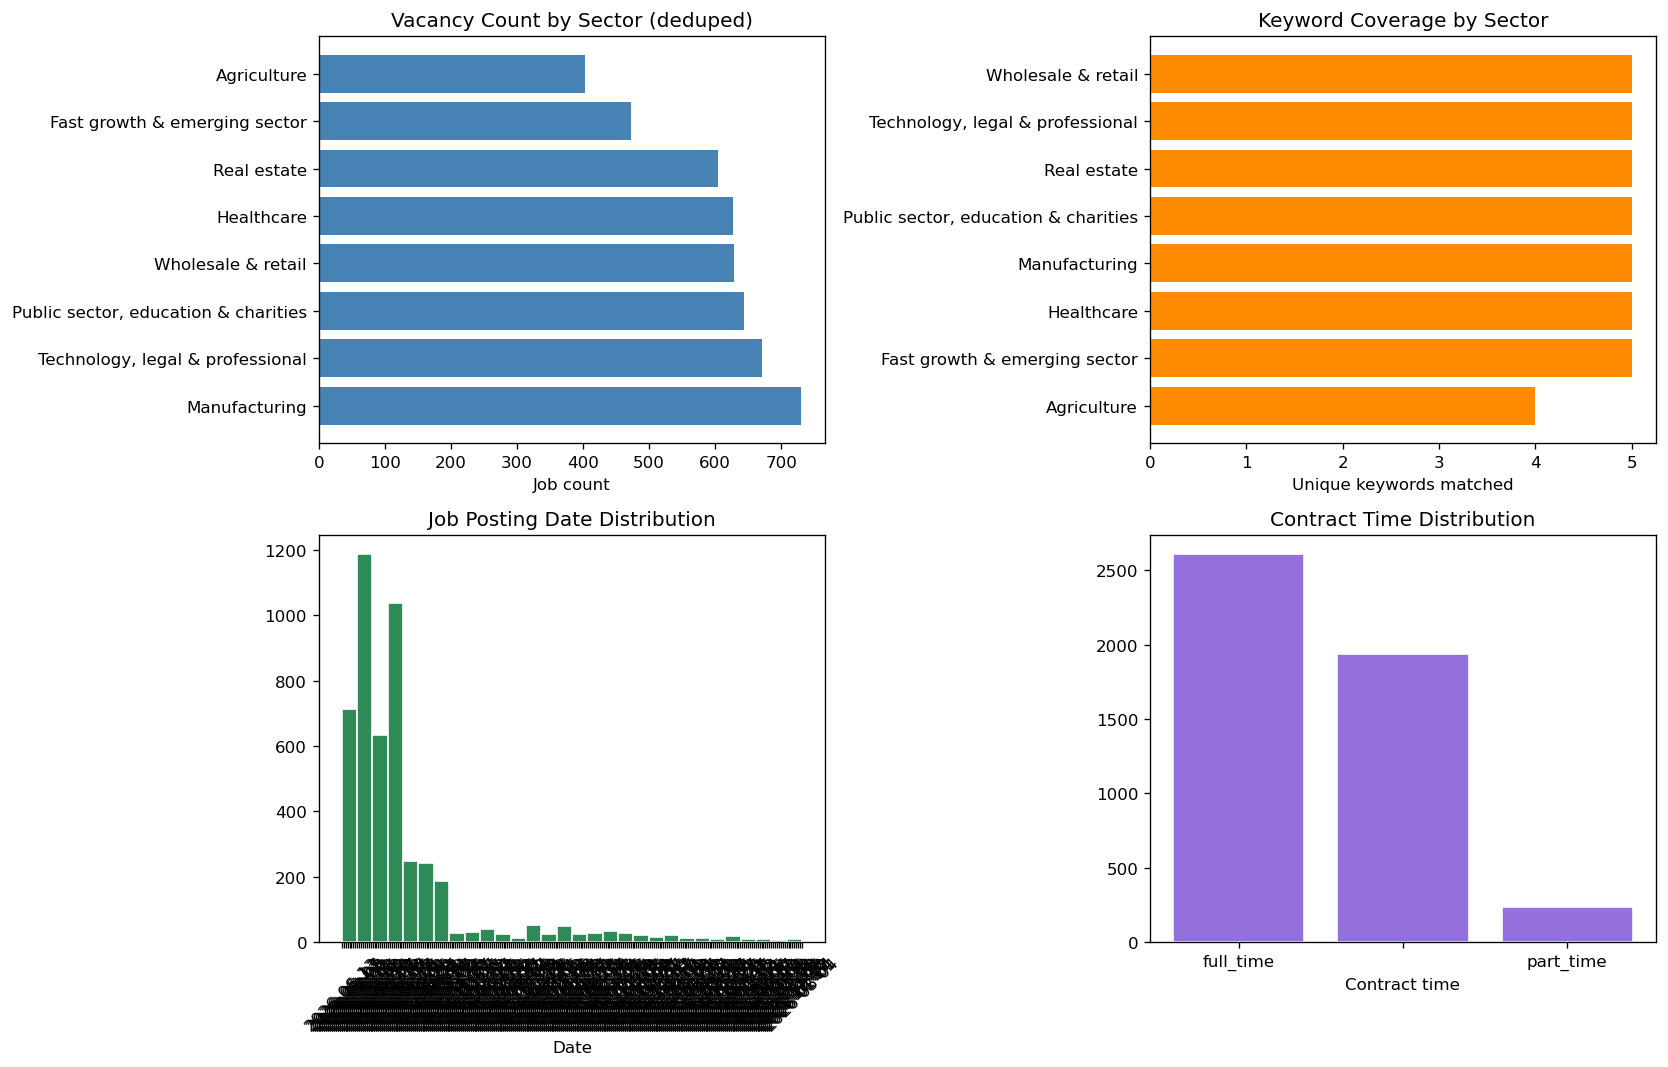

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ① 各行业职位总量
sector_counts = jobs_dedup["sector"].value_counts()
axes[0,0].barh(sector_counts.index, sector_counts.values, color="steelblue")
axes[0,0].set_title("Vacancy Count by Sector (deduped)")
axes[0,0].set_xlabel("Job count")

# ② 关键词覆盖度（每行业命中了几个不同关键词）
kw_coverage = jobs_dedup.groupby("sector")["keyword"].nunique().sort_values()
axes[0,1].barh(kw_coverage.index, kw_coverage.values, color="darkorange")
axes[0,1].set_title("Keyword Coverage by Sector")
axes[0,1].set_xlabel("Unique keywords matched")

# ③ 发布日期分布（只看有日期的）
jobs_dedup["created_dt"] = pd.to_datetime(jobs_dedup["created"], utc=True, errors="coerce")
valid_dates = jobs_dedup["created_dt"].dropna()
axes[1,0].hist(valid_dates.dt.date.astype(str), bins=30, color="seagreen", edgecolor="white")
axes[1,0].set_title("Job Posting Date Distribution")
axes[1,0].set_xlabel("Date")
axes[1,0].tick_params(axis="x", rotation=45)

# ④ 合同类型分布
ct = jobs_dedup["contract_time"].value_counts().head(6)
axes[1,1].bar(ct.index, ct.values, color="mediumpurple", edgecolor="white")
axes[1,1].set_title("Contract Time Distribution")
axes[1,1].set_xlabel("Contract time")

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "sector_hiring_eda.png", bbox_inches="tight")
plt.show()

## 7. Step 3 — 聚合成 4 个子维度评分

| 子维度 | 字段来源 | 含义 |
|--------|----------|------|
| `volume_score` | `vacancy_count` | 该行业当前招聘体量 |
| `recency_score` | `days_since_latest` | 招聘是否持续活跃 |
| `coverage_score` | `query_coverage` + `unique_titles` | 关键词和岗位类型覆盖广度 |
| `breadth_score` | `unique_locations` | 地域扩张广度 |

各子维度先做 **min-max 归一化**，再按权重合成 `sector_hiring_score`（0–100）。

In [11]:
def compute_sector_raw_metrics(jobs_df: pd.DataFrame) -> pd.DataFrame:
    """计算每个 sector 的原始指标（归一化之前）"""
    now = datetime.now(tz=timezone.utc)
    jobs_df = jobs_df.copy()
    jobs_df["created_dt"] = pd.to_datetime(jobs_df["created"], utc=True, errors="coerce")

    metrics = (
        jobs_df.groupby("sector")
        .agg(
            vacancy_count    = ("job_id",     "nunique"),
            query_coverage   = ("keyword",    "nunique"),
            unique_titles    = ("job_title",  "nunique"),
            unique_locations = ("location",   "nunique"),
            latest_post_dt   = ("created_dt", "max"),
        )
        .reset_index()
    )

    # 距今最近发布天数（越小越好）
    metrics["days_since_latest"] = metrics["latest_post_dt"].apply(
        lambda x: (now - x).days if pd.notna(x) else 999
    )

    return metrics


raw_metrics = compute_sector_raw_metrics(jobs_dedup)
print("原始指标：")
raw_metrics[[
    "sector","vacancy_count","query_coverage",
    "unique_titles","unique_locations","days_since_latest"
]]

原始指标：


,sector,vacancy_count,query_coverage,unique_titles,unique_locations,days_since_latest
0,Agriculture,403,4,256,253,0
1,Fast growth & emerging sector,473,5,259,167,0
2,Healthcare,627,5,245,387,0
3,Manufacturing,730,5,277,398,0
4,"Public sector, education & charities",644,5,419,318,0
5,Real estate,604,5,173,319,0
6,"Technology, legal & professional",671,5,256,260,0
7,Wholesale & retail,629,5,164,401,0


In [12]:
def minmax_norm(series: pd.Series) -> pd.Series:
    """min-max 归一化到 [0, 1]"""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - mn) / (mx - mn)


def compute_sector_hiring_score(metrics: pd.DataFrame) -> pd.DataFrame:
    df = metrics.copy()

    # ① volume_score：职位数越多越高
    df["volume_norm"] = minmax_norm(df["vacancy_count"])

    # ② recency_score：距今天数越少越高（取反后归一化）
    df["recency_norm"] = 1 - minmax_norm(df["days_since_latest"].clip(upper=180))

    # ③ coverage_score：关键词覆盖 + 岗位类型多样性
    df["coverage_norm"] = minmax_norm(
        0.5 * minmax_norm(df["query_coverage"]) +
        0.5 * minmax_norm(df["unique_titles"])
    )

    # ④ breadth_score：地域多样性
    df["breadth_norm"] = minmax_norm(df["unique_locations"])

    # ── 合成最终分（加权求和 × 100）────────────────────────
    # 权重：招聘量 40%，新鲜度 25%，覆盖度 20%，广度 15%
    df["sector_hiring_score"] = (
        0.40 * df["volume_norm"]   +
        0.25 * df["recency_norm"]  +
        0.20 * df["coverage_norm"] +
        0.15 * df["breadth_norm"]
    ) * 100

    df["sector_hiring_score"] = df["sector_hiring_score"].round(1)

    return df[[
        "sector",
        "vacancy_count", "query_coverage", "unique_titles",
        "unique_locations", "days_since_latest",
        "volume_norm", "recency_norm", "coverage_norm", "breadth_norm",
        "sector_hiring_score",
    ]]


sector_signals = compute_sector_hiring_score(raw_metrics)
sector_signals.to_csv(SECTOR_SIGNALS_PATH, index=False, encoding="utf-8-sig")
print(f"✓ 行业招聘信号已保存 → {SECTOR_SIGNALS_PATH}")
sector_signals.sort_values("sector_hiring_score", ascending=False)

✓ 行业招聘信号已保存 → ../output/adzuna_sector/sector_hiring_signals.csv


,sector,vacancy_count,query_coverage,unique_titles,unique_locations,days_since_latest,volume_norm,recency_norm,coverage_norm,breadth_norm,sector_hiring_score
3,Manufacturing,730,5,277,398,0,1.000000,0.5,0.660287,0.987179,80.5
4,"Public sector, education & charities",644,5,419,318,0,0.737003,0.5,1.000000,0.645299,71.7
2,Healthcare,627,5,245,387,0,0.685015,0.5,0.583732,0.940171,65.7
6,"Technology, legal & professional",671,5,256,260,0,0.819572,0.5,0.610048,0.397436,63.4
7,Wholesale & retail,629,5,164,401,0,0.691131,0.5,0.389952,1.000000,62.9
5,Real estate,604,5,173,319,0,0.614679,0.5,0.411483,0.649573,55.1
1,Fast growth & emerging sector,473,5,259,167,0,0.214067,0.5,0.617225,0.000000,33.4
0,Agriculture,403,4,256,253,0,0.000000,0.5,0.000000,0.367521,18.0


## 8. 行业评分可视化

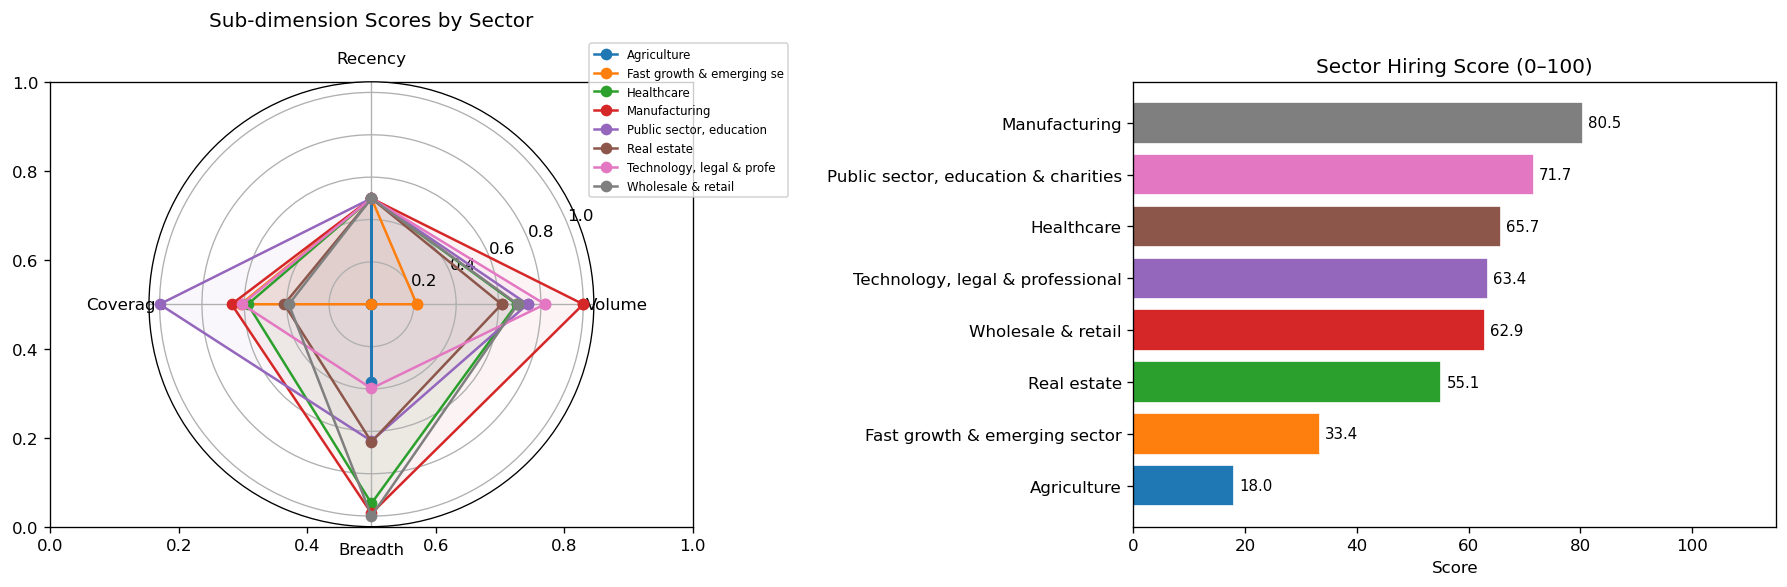

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ① 雷达图（各行业子维度得分）
import numpy as np

sub_cols  = ["volume_norm", "recency_norm", "coverage_norm", "breadth_norm"]
sub_labels = ["Volume", "Recency", "Coverage", "Breadth"]
sectors    = sector_signals["sector"].tolist()
angles     = np.linspace(0, 2 * np.pi, len(sub_cols), endpoint=False).tolist()
angles    += angles[:1]

ax_radar = fig.add_subplot(121, polar=True)
colors = plt.cm.tab10.colors

for i, row in sector_signals.iterrows():
    values = [row[c] for c in sub_cols] + [row[sub_cols[0]]]
    ax_radar.plot(angles, values, "o-", linewidth=1.5,
                  label=row["sector"][:25], color=colors[i % len(colors)])
    ax_radar.fill(angles, values, alpha=0.05, color=colors[i % len(colors)])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(sub_labels, fontsize=10)
ax_radar.set_title("Sub-dimension Scores by Sector", pad=15)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.45, 1.1), fontsize=7)

# ② 综合评分条形图
ranked = sector_signals.sort_values("sector_hiring_score")
ax_bar = axes[1]
bars = ax_bar.barh(
    ranked["sector"], ranked["sector_hiring_score"],
    color=[colors[i % len(colors)] for i in range(len(ranked))],
    edgecolor="white"
)
ax_bar.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax_bar.set_xlim(0, 115)
ax_bar.set_title("Sector Hiring Score (0–100)")
ax_bar.set_xlabel("Score")

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "sector_hiring_scores.png", bbox_inches="tight")
plt.show()

## 9. Step 4 — 合并回公司主表

同一行业的所有公司共享该行业的 `sector_hiring_score`，作为后续 Opportunity Score 的背景调节系数。

In [14]:
master = pd.read_csv(INPUT_PATH, low_memory=False, dtype=str)
print(f"主表记录数: {len(master):,}")

# 确保 sector 名称字段存在
sector_col = None
for candidate in ["primary_sector", "sector_name", "sector_id"]:
    if candidate in master.columns:
        sector_col = candidate
        break

assert sector_col is not None, "主表中找不到行业标签字段，请检查列名"
print(f"使用行业字段: '{sector_col}'")

# 建立 sector 名称映射（兼容 sector_id 为数字的情况）
# 如果主表用的是 sector_id 数字，需要先转成名称再 merge
# 下方假设主表 primary_sector 字段和 SECTOR_KEYWORDS 的 key 一致
merge_on_signals = sector_signals[["sector", "sector_hiring_score",
                                    "vacancy_count", "query_coverage",
                                    "unique_titles", "unique_locations",
                                    "days_since_latest"]].copy()

master_out = master.merge(
    merge_on_signals.rename(columns={"sector": sector_col}),
    on=sector_col,
    how="left"
)

# 没有对应行业数据的公司填 0
master_out["sector_hiring_score"] = (
    pd.to_numeric(master_out["sector_hiring_score"], errors="coerce").fillna(0)
)

master_out.to_csv(COMPANY_OUT_PATH, index=False, encoding="utf-8-sig")

print(f"\n 合并完成 → {COMPANY_OUT_PATH}")
print(f"  主表行数:              {len(master_out):,}")
print(f"  有招聘分的公司数:      {(master_out['sector_hiring_score'] > 0).sum():,}")
print(f"  sector_hiring_score 分布：")
print(master_out["sector_hiring_score"].describe().round(1).to_string())

主表记录数: 3,415,689
使用行业字段: 'primary_sector'

 合并完成 → ../output/adzuna_sector/company_master_with_hiring.csv
  主表行数:              3,415,689
  有招聘分的公司数:      1,882,446
  sector_hiring_score 分布：
count    3415689.0
mean          32.8
std           31.9
min            0.0
25%            0.0
50%           33.4
75%           63.4
max           80.5


In [15]:
# ── 按行业展示合并结果 ────────────────────────────────────────────
print("各行业公司数 × 招聘分：")
master_out.groupby(sector_col)["sector_hiring_score"].agg(
    companies="count",
    hiring_score="first"      # 同行业值相同，取第一个即可
).sort_values("hiring_score", ascending=False)

各行业公司数 × 招聘分：


,companies,hiring_score
primary_sector,,
Manufacturing,231184,80.5
"Public sector, education & charities",158104,71.7
Healthcare,241724,65.7
"Technology, legal & professional",840587,63.4
Fast growth & emerging sector,367454,33.4
Agriculture,43393,18.0
Real Estate,799602,0.0
Wholesale & Retail,733641,0.0


## 10. 输出说明与下一步

### 输出文件

| 文件 | 说明 |
|------|------|
| `sector_jobs_raw.csv` | 原始职位记录，每行一个职位 |
| `sector_hiring_signals.csv` | 每个 sector 的 4 个子维度分 + 综合评分 |
| `company_master_with_hiring.csv` | 主表 + `sector_hiring_score` 合并结果 |
| `sector_hiring_eda.png` | 数据分布图 |
| `sector_hiring_scores.png` | 雷达图 + 评分条形图 |
| `adzuna_sector_cache.sqlite` | API 缓存，断点续跑用 |

### 接入 Opportunity Score

```python
# 下一步：在 Opportunity Score notebook 中
opportunity_score = (
    0.50 * company_filing_score     # Companies House 申报行为
  + 0.30 * sector_hiring_score      # 本 notebook 输出（行业背景）
  + 0.20 * company_age_score        # 公司年龄
)
```

### 关键词迭代建议

如果某个行业的 `vacancy_count` 很低（< 50），说明关键词太窄，  
回到 **Section 2** 补充更多关键词后重新运行即可（缓存不受影响）。
